In [18]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Datensatz herunterladen
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset path:", path)


Dataset path: C:\Users\fhq-e\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [19]:
from pathlib import Path

dataset_path = Path(path)

for file in dataset_path.iterdir():
    print(file)

C:\Users\fhq-e\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


In [20]:
csv_file = dataset_path / "creditcard.csv"

df = pd.read_csv(csv_file)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
df.shape

(284807, 31)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [23]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [24]:
print(df.duplicated().sum())

1081


In [25]:
duplicates = df[df.duplicated()]
duplicates["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [26]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [27]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [28]:
df = df.drop_duplicates()

In [43]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (283726, 31)


In [29]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

## Data Quality Assessment

### Missing Values
No missing values were detected in the dataset.

### Data Types
All features were stored in numeric formats (30 float variables and 1 integer target variable).

### Duplicate Records
The dataset contained 1,081 duplicate transactions (0.38% of all records).

After removing duplicate records:

- Transactions: 283,726
- Normal transactions: 283,253
- Fraudulent transactions: 473

Duplicate removal was performed before model training to avoid potential bias and data redundancy.

In [30]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [31]:
df["Amount"].describe()


count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [32]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


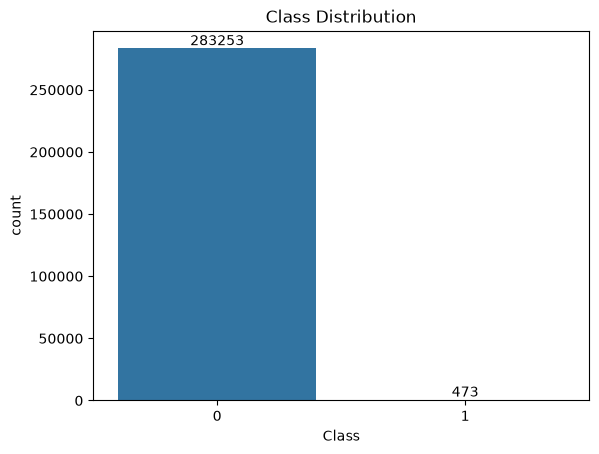

In [33]:
ax = sns.countplot(x="Class", data = df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.show()

In [36]:
fraud_percentage = (
    df["Class"].mean() * 100
)

print(f"Fraud transactions: {fraud_percentage:.4f}%")

Fraud transactions: 0.1667%


### Class Labels

The target variable `Class` represents the transaction type:

- Class 0 = Legitimate transaction
- Class 1 = Fraudulent transaction

After removing duplicate records, fraudulent transactions account for approximately 0.167% of all observations.

This confirms the presence of extreme class imbalance and motivates the use of Precision, Recall, F1-Score and ROC-AUC as primary evaluation metrics.

### Class Distribution

After removing duplicate records, the dataset contains:

- 283,253 legitimate transactions 
- 473 fraudulent transactions 

Fraudulent transactions represent approximately 0.167% of all observations.

The dataset remains highly imbalanced, which makes accuracy an unsuitable performance metric. Therefore, model evaluation focuses on Precision, Recall, F1-Score and ROC-AUC.

## Transaction Amount Analysis

`Amount` and `Time` are the only non-anonymized features in the dataset and are therefore particularly interesting for exploratory analysis.

The transaction amount distribution is highly right-skewed.

- Mean transaction amount: 88.47
- Median transaction amount: 22.00

The substantial difference between the mean and median indicates the presence of a small number of very large transactions that increase the average value.

To better understand potential differences between legitimate and fraudulent transactions, transaction amounts are analyzed separately for both classes.

### Amount Analysis

Fraudulent transactions have a higher average transaction amount than legitimate transactions:

- Mean fraud amount: 123.87
- Mean legitimate amount: 88.41

However, the median transaction amount for fraudulent transactions is considerably lower:

- Median fraud amount: 9.82
- Median legitimate amount: 22.00

This suggests that most fraudulent transactions involve relatively small amounts, while a small number of large fraudulent transactions increase the average value.

Furthermore, the largest transaction amounts in the dataset are observed among legitimate transactions rather than fraudulent ones.

In [38]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,94835.058093,47475.550607,0.0,54233.0,84711.0,139308.0,172792.0
1,473.0,80450.513742,48636.179973,406.0,41203.0,73408.0,129095.0,170348.0


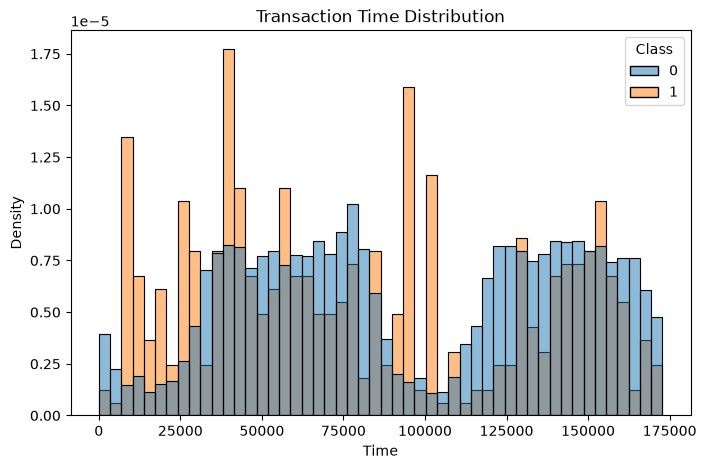

In [39]:
plt.figure(figsize = (8,5))

sns.histplot(data = df, x = "Time", hue = "Class", bins = 50, stat = "density", common_norm = False)
plt.title("Transaction Time Distribution")
plt.show()

## Time Analysis

`Time` represents the number of seconds elapsed between a transaction and the first transaction recorded in the dataset.

To assess whether transaction timing provides useful information for fraud detection, the distribution of transaction times was analyzed separately for legitimate and fraudulent transactions.

### Time Analysis Results

Fraudulent transactions occur throughout the entire observation period and are not concentrated within a specific time window.

The average transaction time for fraudulent transactions (80,451 seconds) is somewhat lower than for legitimate transactions (94,835 seconds). A similar pattern can be observed for the median transaction time.

However, both classes exhibit comparable variability, and their distributions overlap substantially.

These findings suggest that transaction time alone is not a strong predictor of fraudulent activity. While it may contribute some information when combined with other features, it is unlikely to provide substantial predictive power as a standalone variable.

In [40]:
corr_target = (df.corr()["Class"].sort_values(ascending = False))
print(corr_target)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


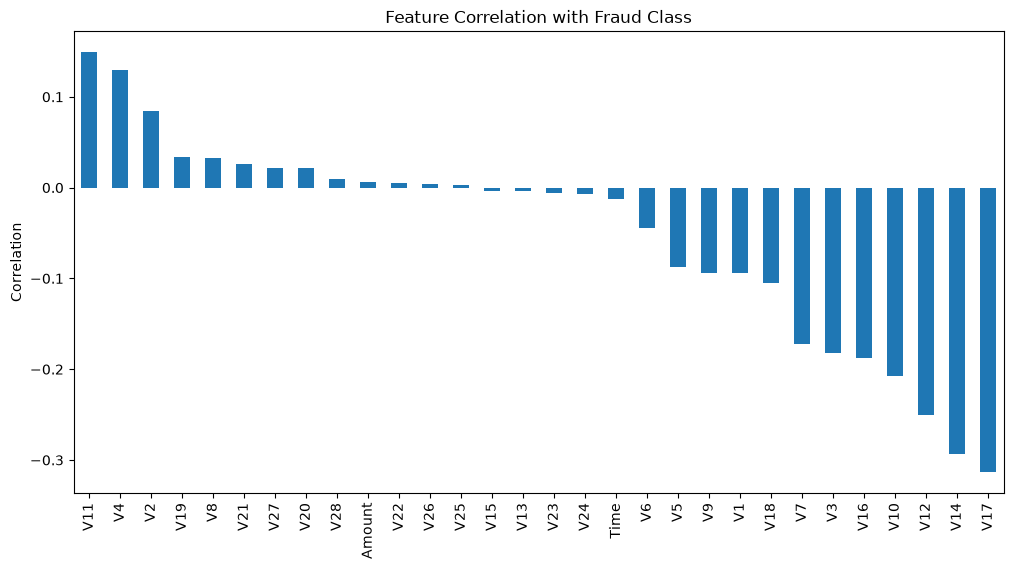

In [41]:
corr_target.drop("Class").plot(kind = "bar", figsize = (12,6))
plt.title("Feature Correlation with Fraud Class")
plt.ylabel("Correlation")
plt.show()

## Correlation Analysis

To identify features most strongly associated with fraudulent transactions, the Pearson correlation coefficient between each feature and the target variable (`Class`) was calculated.

### Strongest Positive Correlations

The features showing the strongest positive correlation with fraud are:

- V11 (0.149)
- V4 (0.129)
- V2 (0.085)

These variables tend to have larger values for fraudulent transactions.

### Strongest Negative Correlations

The strongest negative correlations were observed for:

- V17 (-0.313)
- V14 (-0.293)
- V12 (-0.251)
- V10 (-0.207)
- V16 (-0.187)
- V3 (-0.182)
- V7 (-0.172)

These features appear to be the most informative indicators of fraudulent behavior within the dataset.

### Amount and Time

The non-anonymized features `Amount` and `Time` show only very weak correlations with the target variable.

- Amount: 0.006
- Time: -0.012

This suggests that neither feature is a strong standalone predictor of fraudulent activity. Most predictive information appears to be contained within the anonymized PCA-transformed variables.

## EDA Conclusion

The exploratory data analysis provided several important insights into the credit card fraud detection dataset.

### Data Quality

The dataset is of high quality and required minimal preprocessing.

- No missing values were detected.
- All features were stored in appropriate numeric formats.
- 1,081 duplicate transactions were identified and removed prior to model training.

After cleaning, the dataset contained 283,726 transactions, including 473 fraudulent transactions.

### Class Imbalance

The dataset is extremely imbalanced.

Fraudulent transactions account for only 0.1667% of all observations. This severe imbalance makes accuracy an unsuitable evaluation metric and highlights the importance of Precision, Recall, F1-Score and ROC-AUC for model evaluation.

### Transaction Characteristics

The transaction amount distribution is highly right-skewed.

While fraudulent transactions exhibit a higher average transaction amount than legitimate transactions, their median amount is lower. This indicates that most fraudulent transactions involve relatively small amounts, while a small number of large fraud cases increase the average value.

Transaction time does not appear to be a strong standalone indicator of fraudulent activity. Fraudulent transactions occur throughout the observation period and show a distribution similar to legitimate transactions.

### Feature Relationships

Correlation analysis revealed that the anonymized PCA-transformed features contain most of the predictive information.

The strongest positive correlations with fraudulent activity were observed for:

- V11
- V4
- V2

The strongest negative correlations were observed for:

- V17
- V14
- V12
- V10
- V16

In contrast, the non-anonymized features `Amount` and `Time` showed only weak correlations with the target variable.

### Implications for Modeling

The analysis suggests that successful fraud detection models must address the extreme class imbalance while effectively leveraging the information contained in the PCA-transformed features.

The findings from this exploratory analysis provide the foundation for the subsequent machine learning and deep learning approaches evaluated in this project, including Logistic Regression, Random Forest, Deep Neural Networks and Autoencoder-based anomaly detection.